# NOTEBOOK 04: *PREDICCIÓN*

# IMPORTAR LIBRERÍAS

In [1]:
import pandas as pd
import numpy as np

import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

import seaborn as sns
from tqdm import tqdm
import xgboost as xgb

In [2]:
# Quedan comentadas las librerías referentes a la red neuronal entrenada, al igual que la propia red neuronal, por motivos de eficiencia. 
# En última instancia se descartó su uso pero decidimos mantener el modelo como muestra

# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping

In [3]:
print("Working with these versions of libraries\n")
print("-"*50)
print(f"pandas  version {pd.__version__}")
print(f"numpy   version {np.__version__}")
print(f"sklearn   version {sklearn.__version__}")
print(f"seaborn version {sns.__version__}")

Working with these versions of libraries

--------------------------------------------------
pandas  version 2.2.3
numpy   version 2.2.2
sklearn   version 1.6.1
seaborn version 0.13.2


# FUNCIONES

In [4]:
def calcular_stock_a_reponer(df_estocaje, stock_seguridad_factor=0.2):

    df_estocaje = df_estocaje.copy()

    # Aseguramos que las claves sean texto
    df_estocaje['item'] = df_estocaje['item'].astype(str)
    df_estocaje['store'] = df_estocaje['store'].astype(str)

    # Calculamos el stock de seguridad
    df_estocaje['stock_seguridad'] = df_estocaje['units_sold'] * stock_seguridad_factor

    # Calculamos total stock necesario por item y tienda
    df_estocaje['total_stock_necesario'] = (
        df_estocaje.groupby(['item', 'store'])['units_sold']
        .transform('sum') + df_estocaje['stock_seguridad']
    )

    # Asumimos stock actual = 0
    df_estocaje['stock_actual'] = 0

    # Entonces, todo el total_stock_necesario debe reponerse
    df_estocaje['stock_a_reponer'] = df_estocaje['total_stock_necesario']

    return df_estocaje[['item','store', 'total_stock_necesario', 'stock_actual', 'stock_a_reponer']]

# CARGA DF

In [5]:
# Configuramos pandas para evitar notación científica

pd.options.display.float_format = '{:.2f}'.format

In [6]:
# Mostramos df con columnas enteras:

pd.set_option('display.max_columns', None)

In [7]:
df = pd.read_pickle('data/pickles/df_clustered.pkl')

In [8]:
df.columns

Index(['id', 'item', 'category', 'department', 'store', 'region', 'yearweek',
       'units_sold', 'sell_price', 'year', 'quarter',
       'producto_decreciente_ny', 'producto_creciente_ny',
       'producto_decreciente_boston', 'producto_creciente_boston',
       'producto_decreciente_phi', 'producto_creciente_phi', 'unique_id',
       'event_Buddhist', 'event_ChineeseNewYear', 'event_Christmas',
       'event_Columbus', 'event_Hindu', 'event_Independence',
       'event_JewNewYear', 'event_Juneteenth', 'event_Labour',
       'event_MartinLutherKing', 'event_Memorial', 'event_NewYear',
       'event_President', 'event_RamadanEnds', 'event_RamadanStarts',
       'event_StPatrick', 'event_Superbowl', 'event_Thanksgiving',
       'event_Veterans', 'event_YomKipur', 'event_group_buddhist',
       'event_group_chinese', 'event_group_hindu', 'event_group_islam',
       'event_group_jew', 'event_group_national', 'has_event', 'week', 'date',
       'month', 'season', 'max_wind', 'min_wind', '

In [9]:
df.isnull().sum()

id                        0
item                      0
category                  0
department                0
store                     0
                         ..
rolling_std_3             0
price_change              0
mean_units_by_category    0
cluster_item              0
cluster_store             0
Length: 82, dtype: int64

In [10]:
df.head()


,id,item,category,department,store,region,yearweek,units_sold,sell_price,year,quarter,producto_decreciente_ny,producto_creciente_ny,producto_decreciente_boston,producto_creciente_boston,producto_decreciente_phi,producto_creciente_phi,unique_id,event_Buddhist,event_ChineeseNewYear,event_Christmas,event_Columbus,event_Hindu,event_Independence,event_JewNewYear,event_Juneteenth,event_Labour,event_MartinLutherKing,event_Memorial,event_NewYear,event_President,event_RamadanEnds,event_RamadanStarts,event_StPatrick,event_Superbowl,event_Thanksgiving,event_Veterans,event_YomKipur,event_group_buddhist,event_group_chinese,event_group_hindu,event_group_islam,event_group_jew,event_group_national,has_event,week,date,month,season,max_wind,min_wind,avg_wind,max_rain,avg_rain,max_snow,avg_snow,max_tempmax,min_tempmax,avg_tempmax,max_tempmin,min_tempmin,avg_tempmin,temp_avg_range,has_rain,has_snow,extreme_weather,price_diff_from_median_item,price_region_week_avg,price_per_region_avg_diff,income,lag_1,lag_2,lag_3,diff_lag_1,diff_lag_2,diff_lag_3,rolling_mean_3,rolling_std_3,price_change,mean_units_by_category,cluster_item,cluster_store
0,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,New York,201108,0,5.96,2011,1,True,False,True,False,True,False,ACCESORIES_1_004_NYC_1_201108,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,8,2011-02-21,2,winter,3.70,1.60,2.64,33.50,6.20,81.00,11.57,13.90,2.20,6.59,3.30,-8.90,-2.39,8.97,True,True,0,-0.22,5.18,0.77,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.96,Primavera,Salas de concierto
1,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,New York,201108,0,3.17,2011,1,True,False,True,False,True,False,ACCESORIES_1_005_NYC_1_201108,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,8,2011-02-21,2,winter,3.70,1.60,2.64,33.50,6.20,81.00,11.57,13.90,2.20,6.59,3.30,-8.90,-2.39,8.97,True,True,0,-0.66,5.18,-2.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.96,Otoño,Salas de concierto
2,ACCESORIES_1_006_NYC_1,ACCESORIES_1_006,ACCESORIES,ACCESORIES_1,Greenwich_Village,New York,201108,0,1.26,2011,1,True,False,False,True,False,True,ACCESORIES_1_006_NYC_1_201108,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,8,2011-02-21,2,winter,3.70,1.60,2.64,33.50,6.20,81.00,11.57,13.90,2.20,6.59,3.30,-8.90,-2.39,8.97,True,True,0,-0.07,5.18,-3.92,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.96,Primavera,Salas de concierto
3,ACCESORIES_1_007_NYC_1,ACCESORIES_1_007,ACCESORIES,ACCESORIES_1,Greenwich_Village,New York,201108,0,9.53,2011,1,False,True,False,True,False,True,ACCESORIES_1_007_NYC_1_201108,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,8,2011-02-21,2,winter,3.70,1.60,2.64,33.50,6.20,81.00,11.57,13.90,2.20,6.59,3.30,-8.90,-2.39,8.97,True,True,0,-0.95,5.18,4.35,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.96,Otoño,Salas de concierto
4,ACCESORIES_1_008_NYC_1,ACCESORIES_1_008,ACCESORIES,ACCESORIES_1,Greenwich_Village,New York,201108,14,0.56,2011,1,True,False,True,False,True,False,ACCESORIES_1_008_NYC_1_201108,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,8,2011-02-21,2,winter,3.70,1.60,2.64,33.50,6.20,81.00,11.57,13.90,2.20,6.59,3.30,-8.90,-2.39,8.97,True,True,0,-0.08,5.18,-4.63,7.82,15.00,49.00,22.00,15.00,49.00,22.00,26.00,19.92,-0.05,3.96,Metales,Salas de concierto


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8232297 entries, 0 to 8232296
Data columns (total 82 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   id                           object        
 1   item                         object        
 2   category                     object        
 3   department                   object        
 4   store                        object        
 5   region                       object        
 6   yearweek                     object        
 7   units_sold                   int64         
 8   sell_price                   float64       
 9   year                         int64         
 10  quarter                      int32         
 11  producto_decreciente_ny      bool          
 12  producto_creciente_ny        bool          
 13  producto_decreciente_boston  bool          
 14  producto_creciente_boston    bool          
 15  producto_decreciente_phi     bool          
 16  

# FEATURE PREPARATION

In [12]:
print(f'''
Columnas con dtype object:
{list(df.select_dtypes('object').columns)}

Columnas con dtype bool:
{list(df.select_dtypes('bool').columns)}
''')


Columnas con dtype object:
['id', 'item', 'category', 'department', 'store', 'region', 'yearweek', 'unique_id', 'season', 'cluster_item', 'cluster_store']

Columnas con dtype bool:
['producto_decreciente_ny', 'producto_creciente_ny', 'producto_decreciente_boston', 'producto_creciente_boston', 'producto_decreciente_phi', 'producto_creciente_phi', 'has_rain', 'has_snow']



Pasamos las booleanas a 1 y 0

In [13]:
LISTA_BOOL = list(df.select_dtypes('bool').columns)

for col in LISTA_BOOL:
    df[col] = np.where(df[col] == True, 1, 0)

Establecemos 'unique_id' como índice y eliminamos 'id'

In [14]:
df.set_index('unique_id',inplace=True)
df.drop(columns='id', inplace=True)

Damos a yearweek formato int

In [15]:
df['yearweek'] = df['yearweek'].astype(int)

Label encoding para el resto de variables.

In [16]:
# Variables categóricas
cat_cols = ['item', 'category', 'department', 'store', 'region']

# Label Encoding
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [17]:
LISTA_OHE = list(df.select_dtypes('object').columns)
LISTA_OHE

['season', 'cluster_item', 'cluster_store']

In [18]:
df = pd.get_dummies(df, columns = LISTA_OHE, dtype=int)

In [19]:
df.drop(columns='income', inplace=True)

# PARTICIÓN TRAIN-TEST-VALIDATION

- Vamos a dejar aproximadamente el 85% de los datos para train.
- Para test dejaremos las últimas 4 semanas (la idea es predecir ventas de 4 en 4 semanas).
- El resto de los datos serán para validation.

In [20]:
print(df['date'].min())
print(df['date'].max())

2011-02-21 00:00:00
2016-04-18 00:00:00


In [21]:
sorted(list(df["date"].unique()))

[Timestamp('2011-02-21 00:00:00'),
 Timestamp('2011-02-28 00:00:00'),
 Timestamp('2011-03-07 00:00:00'),
 Timestamp('2011-03-14 00:00:00'),
 Timestamp('2011-03-21 00:00:00'),
 Timestamp('2011-03-28 00:00:00'),
 Timestamp('2011-04-04 00:00:00'),
 Timestamp('2011-04-11 00:00:00'),
 Timestamp('2011-04-18 00:00:00'),
 Timestamp('2011-04-25 00:00:00'),
 Timestamp('2011-05-02 00:00:00'),
 Timestamp('2011-05-09 00:00:00'),
 Timestamp('2011-05-16 00:00:00'),
 Timestamp('2011-05-23 00:00:00'),
 Timestamp('2011-05-30 00:00:00'),
 Timestamp('2011-06-06 00:00:00'),
 Timestamp('2011-06-13 00:00:00'),
 Timestamp('2011-06-20 00:00:00'),
 Timestamp('2011-06-27 00:00:00'),
 Timestamp('2011-07-04 00:00:00'),
 Timestamp('2011-07-11 00:00:00'),
 Timestamp('2011-07-18 00:00:00'),
 Timestamp('2011-07-25 00:00:00'),
 Timestamp('2011-08-01 00:00:00'),
 Timestamp('2011-08-08 00:00:00'),
 Timestamp('2011-08-15 00:00:00'),
 Timestamp('2011-08-22 00:00:00'),
 Timestamp('2011-08-29 00:00:00'),
 Timestamp('2011-09-

In [22]:
df["date"].dt.year.value_counts().sort_index()


date
2011    1372047
2012    1585480
2013    1585480
2014    1585480
2015    1585480
2016     518330
Name: count, dtype: int64

In [23]:
print(f"El número de semanas que tenemos es: {df['date'].nunique()}")

El número de semanas que tenemos es: 269


In [24]:
train_index = sorted(list(df["date"].unique()))[:-41]

valida_index = sorted(list(df["date"].unique()))[-41:-4]

test_index = sorted(list(df["date"].unique()))[-4:]

In [25]:
print(f"Our train index is {train_index[:2]} - ... - {train_index[-2:]}\n")
print(f"Our validation index is {valida_index}\n")
print(f"Our test/prediction index is {test_index}\n")

Our train index is [Timestamp('2011-02-21 00:00:00'), Timestamp('2011-02-28 00:00:00')] - ... - [Timestamp('2015-06-29 00:00:00'), Timestamp('2015-07-06 00:00:00')]

Our validation index is [Timestamp('2015-07-13 00:00:00'), Timestamp('2015-07-20 00:00:00'), Timestamp('2015-07-27 00:00:00'), Timestamp('2015-08-03 00:00:00'), Timestamp('2015-08-10 00:00:00'), Timestamp('2015-08-17 00:00:00'), Timestamp('2015-08-24 00:00:00'), Timestamp('2015-08-31 00:00:00'), Timestamp('2015-09-07 00:00:00'), Timestamp('2015-09-14 00:00:00'), Timestamp('2015-09-21 00:00:00'), Timestamp('2015-09-28 00:00:00'), Timestamp('2015-10-05 00:00:00'), Timestamp('2015-10-12 00:00:00'), Timestamp('2015-10-19 00:00:00'), Timestamp('2015-10-26 00:00:00'), Timestamp('2015-11-02 00:00:00'), Timestamp('2015-11-09 00:00:00'), Timestamp('2015-11-16 00:00:00'), Timestamp('2015-11-23 00:00:00'), Timestamp('2015-11-30 00:00:00'), Timestamp('2015-12-07 00:00:00'), Timestamp('2015-12-14 00:00:00'), Timestamp('2015-12-21 00:00

In [26]:
X_train = df[df["date"].isin(train_index)].drop(['units_sold', "date"], axis=1)
Y_train = df[df["date"].isin(train_index)]['units_sold']

X_valida = df[df["date"].isin(valida_index)].drop(['units_sold', "date"], axis=1)
Y_valida = df[df["date"].isin(valida_index)]['units_sold']

X_test = df[df["date"].isin(test_index)].drop(['units_sold', "date"], axis=1)
Y_test = df[df["date"].isin(test_index)]['units_sold']

In [27]:
# Comprobación de que se ha hecho correctamente el split

print(f'''
Shape df original:{df.shape}

Shape train: 
    X {X_train.shape}
    Y {Y_train.shape}

Shape validation: 
    X {X_valida.shape}
    Y {Y_valida.shape}
    
Shape test: 
    X {X_test.shape}
    Y {Y_test.shape}

Suma de filas de train, validation y test / Valor que debería tener:
{X_train.shape[0] + X_valida.shape[0] + X_test.shape[0]}
{df.shape[0]}
''')

total_split_rows = X_train.shape[0] + X_valida.shape[0] + X_test.shape[0]
original_rows = df.shape[0]

if total_split_rows != original_rows:
    print("OJO: El número total de filas tras el split no coincide con el original.")
else:
    print("Todo bien: el split conserva todas las filas.")



Shape df original:(8232297, 91)

Shape train: 
    X (6951717, 89)
    Y (6951717,)

Shape validation: 
    X (1158620, 89)
    Y (1158620,)
    
Shape test: 
    X (121960, 89)
    Y (121960,)

Suma de filas de train, validation y test / Valor que debería tener:
8232297
8232297

Todo bien: el split conserva todas las filas.


# MODELO

In [28]:
model = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=9,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=30,
    eval_metric="rmse", 
    random_state=42
)

model.fit(
    X_train, Y_train,
    eval_set=[(X_train, Y_train), (X_valida, Y_valida)], 
    verbose=True
)

[0]	validation_0-rmse:23.81028	validation_1-rmse:21.50518
[1]	validation_0-rmse:23.58344	validation_1-rmse:21.29838
[2]	validation_0-rmse:23.35883	validation_1-rmse:21.09201
[3]	validation_0-rmse:23.13596	validation_1-rmse:20.88849
[4]	validation_0-rmse:22.94095	validation_1-rmse:20.71178
[5]	validation_0-rmse:22.72383	validation_1-rmse:20.51205
[6]	validation_0-rmse:22.50785	validation_1-rmse:20.31500
[7]	validation_0-rmse:22.29437	validation_1-rmse:20.11979
[8]	validation_0-rmse:22.08326	validation_1-rmse:19.92705
[9]	validation_0-rmse:21.88172	validation_1-rmse:19.74294
[10]	validation_0-rmse:21.67500	validation_1-rmse:19.55262
[11]	validation_0-rmse:21.47212	validation_1-rmse:19.36749
[12]	validation_0-rmse:21.28492	validation_1-rmse:19.19635
[13]	validation_0-rmse:21.08468	validation_1-rmse:19.01214
[14]	validation_0-rmse:20.88632	validation_1-rmse:18.83123
[15]	validation_0-rmse:20.68941	validation_1-rmse:18.65146
[16]	validation_0-rmse:20.49510	validation_1-rmse:18.47422
[17]	va

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=30,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=800, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

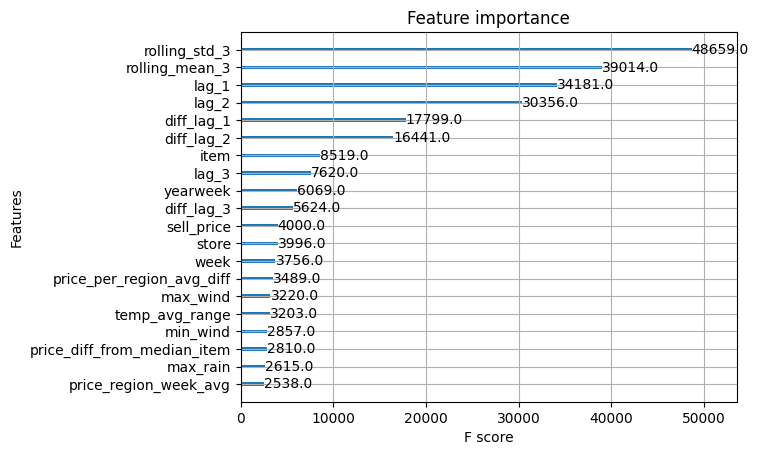

In [29]:
xgb.plot_importance(model, max_num_features=20)


Calculamos el RMSE y MSE en los diferentes conjuntos de datos

In [30]:
Y_train_predict = model.predict(X_train)
Y_valida_predict = model.predict(X_valida)

rmse_train = np.sqrt(
    mean_squared_error(
        y_true = Y_train,
        y_pred = Y_train_predict
    )
)

rmse_valida = np.sqrt(
    mean_squared_error(
        y_true = Y_valida,
        y_pred = Y_valida_predict
    )
)

rmse_train= str(round(rmse_train, 3)).replace(".", "_")
rmse_valida = str(round(rmse_valida, 3)).replace(".", "_")

In [31]:
print(f"Train RMSE: {rmse_train}")
print(f"Validation RMSE: {rmse_valida}")

Train RMSE: 2_041
Validation RMSE: 2_205


In [32]:

val_preds = model.predict(X_valida)
rmse = mean_squared_error(Y_valida, val_preds)
print(f"MSE validación: {rmse:.2f}")


MSE validación: 4.86


In [33]:
Y_test_predict = model.predict(X_test)

rmse_test = np.sqrt(
    mean_squared_error(
        y_true = Y_test,
        y_pred = Y_test_predict
    )
)

rmse_test = str(round(rmse_test, 3)).replace(".", "_")
print(f"Test RMSE: {rmse_test}")

Test RMSE: 1_835


In [34]:
fechas_val = df[df["date"].isin(valida_index)]["date"].values


A continuación ejecutamos diferentes gráficos para comprobar el rendimiento del modelo de forma más visual

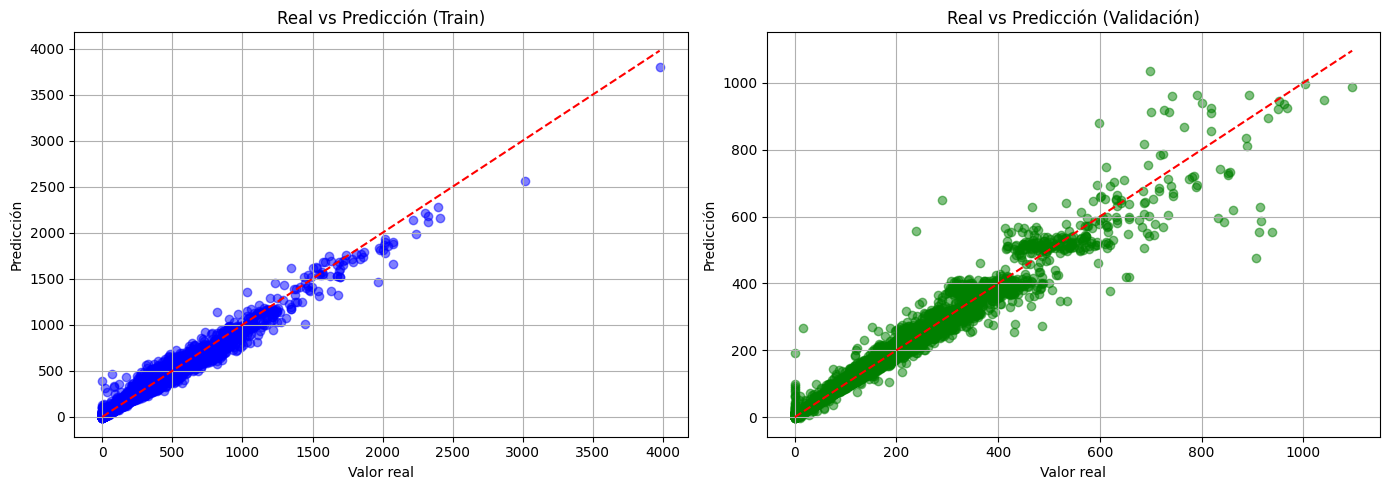

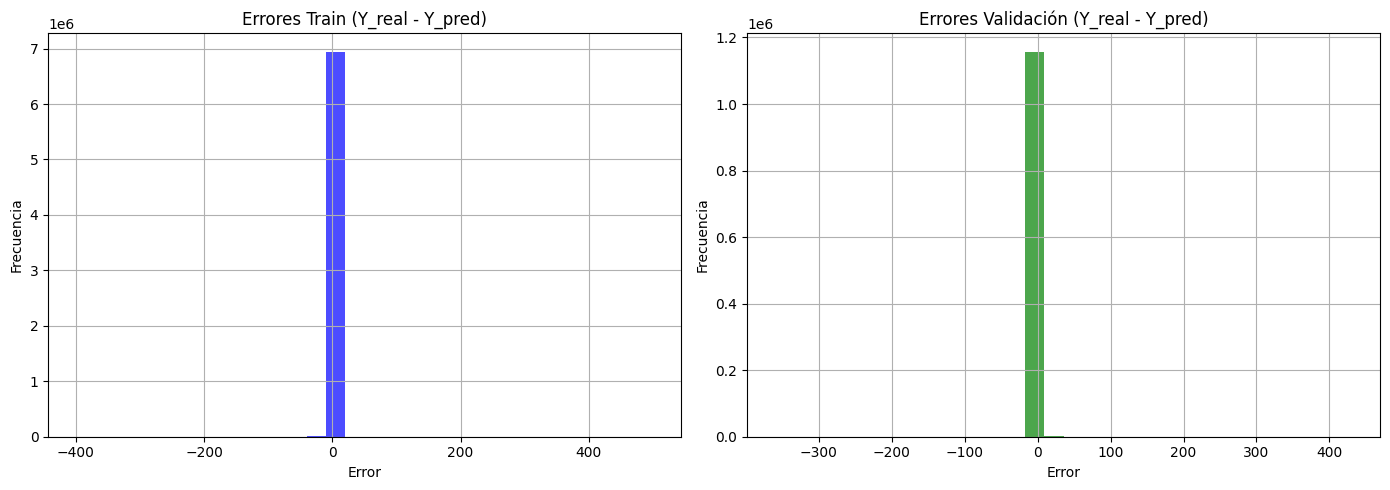

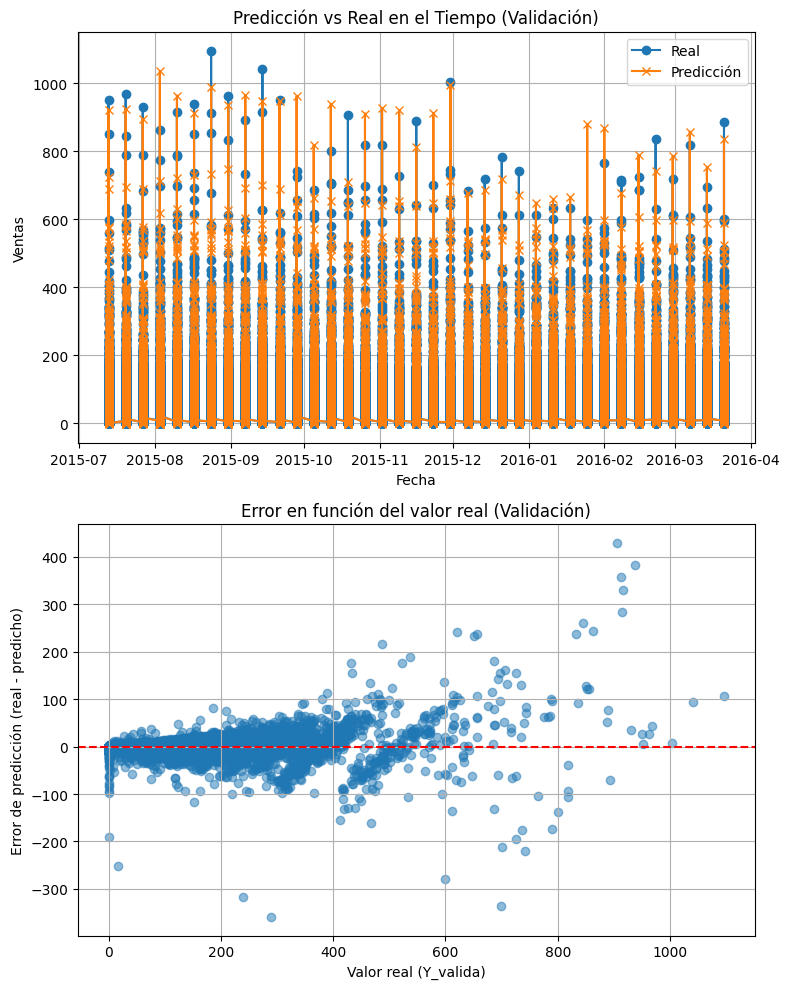

In [35]:
import matplotlib.pyplot as plt

# Real vs Predicción
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
axes[0].scatter(Y_train, Y_train_predict, alpha=0.5, color='blue', label='Train')
axes[0].plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], 'r--')
axes[0].set_title('Real vs Predicción (Train)')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Predicción')
axes[0].grid(True)

# Validación
axes[1].scatter(Y_valida, Y_valida_predict, alpha=0.5, color='green', label='Validación')
axes[1].plot([Y_valida.min(), Y_valida.max()], [Y_valida.min(), Y_valida.max()], 'r--')
axes[1].set_title('Real vs Predicción (Validación)')
axes[1].set_xlabel('Valor real')
axes[1].set_ylabel('Predicción')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Histogramas de Errores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

errores_train = Y_train - Y_train_predict
axes[0].hist(errores_train, bins=30, color='blue', alpha=0.7)
axes[0].set_title("Errores Train (Y_real - Y_pred)")
axes[0].set_xlabel("Error")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(True)

errores_val = Y_valida - Y_valida_predict
axes[1].hist(errores_val, bins=30, color='green', alpha=0.7)
axes[1].set_title("Errores Validación (Y_real - Y_pred)")
axes[1].set_xlabel("Error")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(True)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(2, 1, figsize=(8, 10))

# Curva Temporal
ax[0].plot(fechas_val, Y_valida, label="Real", marker='o')
ax[0].plot(fechas_val, Y_valida_predict, label="Predicción", marker='x')
ax[0].set_title("Predicción vs Real en el Tiempo (Validación)")
ax[0].set_xlabel("Fecha")
ax[0].set_ylabel("Ventas")
ax[0].legend()
ax[0].grid(True)

#Error de predicción
errores = Y_valida - Y_valida_predict
ax[1].scatter(Y_valida, errores, alpha=0.5)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_xlabel('Valor real (Y_valida)')
ax[1].set_ylabel('Error de predicción (real - predicho)')
ax[1].set_title('Error en función del valor real (Validación)')
ax[1].grid(True)

plt.tight_layout()
plt.show()


## RED NEURONAL

In [36]:
# df2 = df.copy()

In [37]:
# df2.info()

In [38]:
# df2.shape

In [39]:
# X_train = df2[df2["date"].isin(train_index)].drop(['units_sold', "date"], axis=1)
# Y_train = df2[df2["date"].isin(train_index)]['units_sold']

# X_valida = df2[df2["date"].isin(valida_index)].drop(['units_sold', "date"], axis=1)
# Y_valida = df2[df2["date"].isin(valida_index)]['units_sold']

# X_test = df2[df2["date"].isin(test_index)].drop(['units_sold', "date"], axis=1)
# Y_test = df2[df2["date"].isin(test_index)]['units_sold']

In [40]:
# # MAPE personalizado
# def mean_absolute_percentage_error(y_true, y_pred):
#     y_true, y_pred = np.array(y_true), np.array(y_pred)
#     return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

# # Escalado de datos
# scaler_X = StandardScaler()
# X_train_scaled = scaler_X.fit_transform(X_train)
# X_valida_scaled = scaler_X.transform(X_valida)
# X_test_scaled = scaler_X.transform(X_test)

# scaler_y = StandardScaler()
# y_train_scaled = scaler_y.fit_transform(Y_train.values.reshape(-1, 1))
# Y_valida_scaled = scaler_y.transform(Y_valida.values.reshape(-1, 1))
# y_test_scaled = scaler_y.transform(Y_test.values.reshape(-1, 1))

# # Modelo secuencial
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# model = Sequential([
#     Dense(256, input_shape=(X_train_scaled.shape[1],), activation='relu'),
#     BatchNormalization(),
#     Dropout(0.3),
    
#     Dense(128, activation='relu'),
#     BatchNormalization(),
#     Dropout(0.3),
    
#     Dense(64, activation='relu'),
#     Dropout(0.2),
    
#     Dense(1)  # Regresión
# ])

# model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])

# callbacks = [
#     EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1)
# ]

# # Entrenamiento
# history = model.fit(
#     X_train_scaled, y_train_scaled,
#     validation_data=(X_valida_scaled, Y_valida_scaled),
#     epochs=100,
#     batch_size=64,
#     callbacks=callbacks,
#     verbose=1
# )

# #EVALUACIÓN FINAL

# # Predicciones y desescalado
# y_pred_scaled = model.predict(X_test_scaled)
# y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()
# y_true = Y_test.values.ravel()

# # Métricas
# mse = mean_squared_error(y_true, y_pred)
# mae = mean_absolute_error(y_true, y_pred)
# r2 = r2_score(y_true, y_pred)
# mape = mean_absolute_percentage_error(y_true, y_pred)

# print(f"[INFO] Test MSE:  {mse:.4f}")
# print(f"[INFO] Test MAE:  {mae:.4f} unidades")
# print(f"[INFO] Test R²:   {r2:.4f}")
# print(f"[INFO] Test MAPE: {mape:.2f}%")

# #GRÁFICOS

# # Gráfico de pérdida
# plt.figure(figsize=(6, 4))
# plt.title("Evolución de pérdida durante el entrenamiento")
# plt.plot(history.history['loss'], label='Train Loss')
# plt.plot(history.history['val_loss'], label='Val Loss')
# plt.xlabel("Épocas")
# plt.ylabel("Loss (MSE)")
# plt.legend()
# plt.grid(True)
# plt.show()

# # Gráfico de pred vs real
# plt.figure(figsize=(6, 6))
# plt.title("Predicción vs Valores Reales")
# plt.scatter(y_true, y_pred, alpha=0.3)
# plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
# plt.xlabel("Valor Real")
# plt.ylabel("Predicción")
# plt.grid(True)
# plt.show()


# Predicciones 4 semanas


Visualizamos tendencias y comportamientos esperados

In [41]:
serie_temporal = df.groupby(['item', 'store', 'date'])['units_sold'].sum().reset_index()
serie_temporal


,item,store,date,units_sold
0,0,0,2011-02-21,0
1,0,0,2011-02-28,0
2,0,0,2011-03-07,0
3,0,0,2011-03-14,0
4,0,0,2011-03-21,0
...,...,...,...,...
8201802,3048,9,2016-03-21,11
8201803,3048,9,2016-03-28,28
8201804,3048,9,2016-04-04,22
8201805,3048,9,2016-04-11,17


Generamos un df con las variables para poder predecir las ventas de las próximas 4 semanas

In [42]:
df_pred_futuro = df.copy()


In [43]:
futuras_predicciones = []

# Última fecha con datos reales
last_date = df["date"].max()

# Generamos 4 semanas futuras
for i in tqdm(range(1, 5)):
    new_date = last_date + pd.Timedelta(weeks=i)

    # Creamos base con todas las combinaciones item-store en el último día real
    base_semana = df_pred_futuro[df_pred_futuro["date"] == last_date][
        ["item", "store", "region", "category", "department"]
    ].copy()

    base_semana["date"] = new_date
    base_semana["year"] = new_date.year
    base_semana["month"] = new_date.month
    base_semana["week"] = new_date.isocalendar()[1]
    base_semana["quarter"] = (new_date.month - 1) // 3 + 1
    base_semana["yearweek"] = f"{new_date.year}{str(base_semana['week'].values[0]).zfill(2)}"
    base_semana["yearweek"] = base_semana["yearweek"].astype(int)

    # Forzamos season_spring = 1 y otras en 0
    base_semana["season_spring"] = 1
    base_semana["season_summer"] = 0
    base_semana["season_autumn"] = 0
    base_semana["season_winter"] = 0

    # Definimos columnas extra
    columnas_extra = [
        'event_Christmas', 'event_Thanksgiving', 'event_NewYear',
        'avg_tempmax', 'avg_rain', 'avg_snow', 'avg_wind',
        'has_event', 'max_wind', 'min_wind', 'max_rain', 'max_snow',
        'max_tempmax', 'min_tempmax', 'max_tempmin', 'min_tempmin',
        'avg_tempmin', 'temp_avg_range', 'has_rain', 'has_snow', 'extreme_weather',
        'sell_price', 'price_per_region_avg_diff', 'price_diff_from_median_item'
    ]

    # Verificamos que existan en el df original
    columnas_extra_existentes = [col for col in columnas_extra if col in df.columns]

    # Obtener últimos valores por item-store
    df_extra = df.sort_values('date').groupby(['item', 'store'], as_index=False).last()

    # Merge con base_semana
    base_semana = base_semana.merge(
        df_extra[['item', 'store'] + columnas_extra_existentes],
        on=['item', 'store'],
        how='left'
    )

    # LAGs de ventas
    for lag in [1, 2, 3]:
        lag_date = new_date - pd.Timedelta(weeks=lag)
        lag_values = df_pred_futuro[
            df_pred_futuro["date"] == lag_date
        ].set_index(["item", "store"])["units_sold"]

        base_semana = base_semana.set_index(["item", "store"])
        base_semana[f"lag_{lag}"] = lag_values
        base_semana = base_semana.reset_index()

    # Features derivadas de los lags
    base_semana["diff_lag_1"] = base_semana["lag_1"] - base_semana["lag_2"]
    base_semana["diff_lag_2"] = base_semana["lag_2"] - base_semana["lag_3"]
    base_semana["diff_lag_3"] = base_semana["lag_3"] - base_semana["lag_1"]
    base_semana["rolling_mean_3"] = base_semana[["lag_1", "lag_2", "lag_3"]].mean(axis=1)
    base_semana["rolling_std_3"] = base_semana[["lag_1", "lag_2", "lag_3"]].std(axis=1)

    # Rellenamos otras columnas faltantes con 0
    for col in df.columns:
        if col not in base_semana.columns and col not in ["units_sold", "date"]:
            base_semana[col] = 0

    # Aseguramos el orden correcto de las columnas
    X_next = base_semana[df.drop(['units_sold', 'date'], axis=1).columns]

    # Predicción
    y_pred = model.predict(X_next)

    # Redondeamos
    y_pred = np.round(np.maximum(y_pred, 0)).astype(int)

    # Guardamos predicción
    base_semana["units_sold"] = y_pred
    df_pred_futuro = pd.concat([df_pred_futuro, base_semana], ignore_index=True)
    futuras_predicciones.append(base_semana)

# DataFrame final con las 4 semanas futuras
df_pred_futuro = pd.concat(futuras_predicciones, ignore_index=True)


100%|██████████| 4/4 [01:44<00:00, 26.14s/it]


In [44]:
df_pred_futuro["week"] = df_pred_futuro["date"].dt.isocalendar().week
df_pred_futuro["year"] = df_pred_futuro["date"].dt.year

ventas_semanales = (
    df_pred_futuro.groupby(["item", "store", "year", "week"])["units_sold"]
    .sum()
    .reset_index()
    .sort_values(["item", "year", "week"])
)
ventas_semanales.head(10)



,item,store,year,week,units_sold
0,0,0,2016,17,3
4,0,1,2016,17,1
8,0,2,2016,17,12
12,0,3,2016,17,3
16,0,4,2016,17,2
20,0,5,2016,17,0
24,0,6,2016,17,3
28,0,7,2016,17,2
32,0,8,2016,17,6
36,0,9,2016,17,2


Agrupamos ventas semanales totales por artículo

In [45]:
ventas_semanales_simple = (
    df_pred_futuro.groupby(["item", df_pred_futuro["date"].dt.isocalendar().week])["units_sold"]
    .sum()
    .reset_index()
    .rename(columns={"week": "semana_predicha"})
)
ventas_semanales_simple.head(10)


,item,semana_predicha,units_sold
0,0,17,34
1,0,18,30
2,0,19,43
3,0,20,33
4,1,17,16
5,1,18,14
6,1,19,22
7,1,20,16
8,2,17,17
9,2,18,28


Agrupamos las predicciones por artículos y sumar las ventas totales predichas para cada artículo


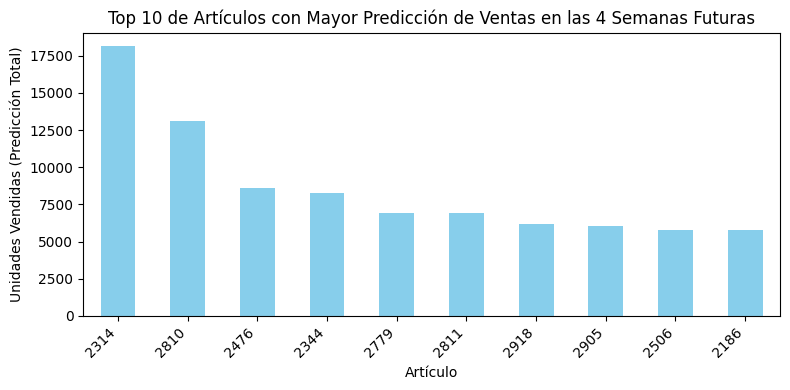

In [46]:
top_10_predicciones = df_pred_futuro.groupby('item')['units_sold'].sum().nlargest(10)

plt.figure(figsize=(8, 4))
top_10_predicciones.plot(kind='bar', color='skyblue')

plt.title('Top 10 de Artículos con Mayor Predicción de Ventas en las 4 Semanas Futuras')
plt.xlabel('Artículo')
plt.ylabel('Unidades Vendidas (Predicción Total)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


Predicción de ventas totales para 4 semanas

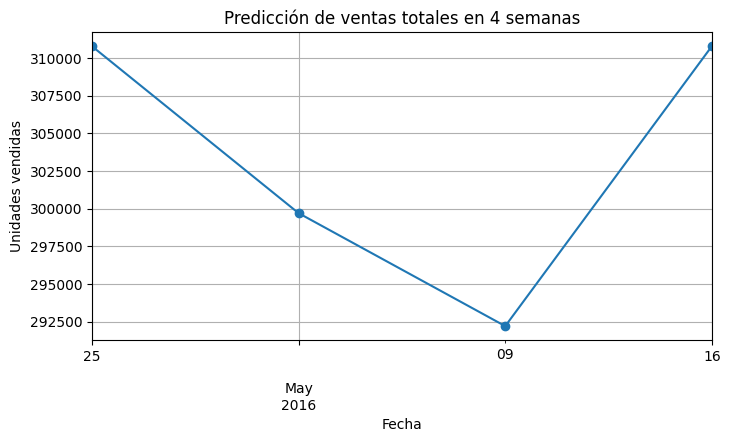

In [47]:
df_pred_futuro.groupby("date")["units_sold"].sum().plot(figsize=(8,4), marker='o')
plt.title("Predicción de ventas totales en 4 semanas")
plt.ylabel("Unidades vendidas")
plt.xlabel("Fecha")
plt.grid(True)
plt.show()


Tendencia de ventas por tienda para 4 semanas

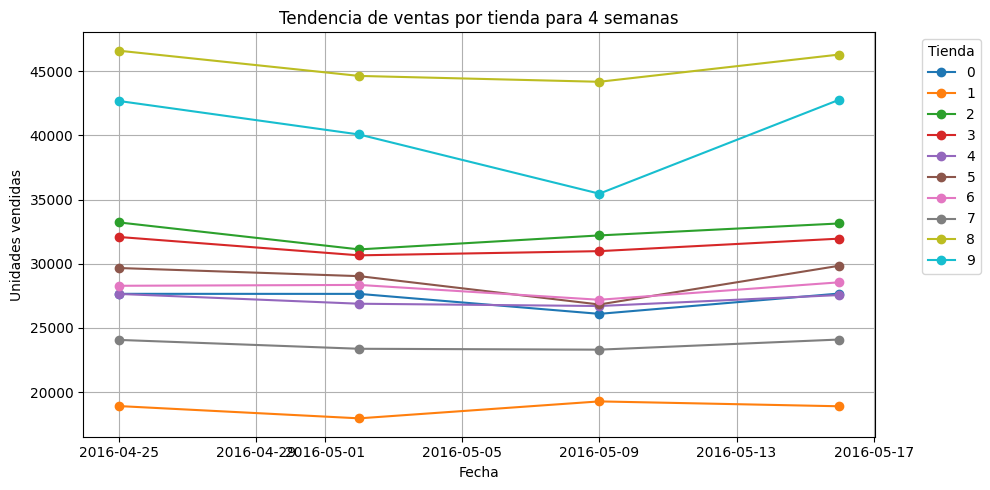

In [48]:
ventas_tienda = df_pred_futuro.groupby(["date", "store"])["units_sold"].sum().reset_index()

# Creamos el gráfico
plt.figure(figsize=(10, 5))
for tienda in ventas_tienda["store"].unique():
    datos_tienda = ventas_tienda[ventas_tienda["store"] == tienda]
    plt.plot(datos_tienda["date"], datos_tienda["units_sold"], marker='o', label=tienda)

plt.title("Tendencia de ventas por tienda para 4 semanas")
plt.xlabel("Fecha")
plt.ylabel("Unidades vendidas")
plt.legend(title="Tienda", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


# Previsión de estocaje

- Para el cálculo de stock emplearemos la desviación estándar del modelo en el set de validación.
- Calcularemos el error de las predicciones y la std, agrupado por item y tienda, en el set de validación.
- Multiplicaremos esta std por 1.96 para un intervalo de confianza del 95%.
- Lo aplicaremos a las predicciones de venta por item y tienda para calcular stock con margen de seguridad.

In [49]:
valida_std_df = X_valida.copy()

valida_std_df['predictions'] = Y_valida_predict
valida_std_df['real_units_sold'] = df[df["date"].isin(valida_index)]['units_sold']

#Diferencia entre predicción y realidad
valida_std_df['error'] = valida_std_df['real_units_sold'] - valida_std_df['predictions']

valida_std_df.head()

,item,category,department,store,region,yearweek,sell_price,year,quarter,producto_decreciente_ny,producto_creciente_ny,producto_decreciente_boston,producto_creciente_boston,producto_decreciente_phi,producto_creciente_phi,event_Buddhist,event_ChineeseNewYear,event_Christmas,event_Columbus,event_Hindu,event_Independence,event_JewNewYear,event_Juneteenth,event_Labour,event_MartinLutherKing,event_Memorial,event_NewYear,event_President,event_RamadanEnds,event_RamadanStarts,event_StPatrick,event_Superbowl,event_Thanksgiving,event_Veterans,event_YomKipur,event_group_buddhist,event_group_chinese,event_group_hindu,event_group_islam,event_group_jew,event_group_national,has_event,week,month,max_wind,min_wind,avg_wind,max_rain,avg_rain,max_snow,avg_snow,max_tempmax,min_tempmax,avg_tempmax,max_tempmin,min_tempmin,avg_tempmin,temp_avg_range,has_rain,has_snow,extreme_weather,price_diff_from_median_item,price_region_week_avg,price_per_region_avg_diff,lag_1,lag_2,lag_3,diff_lag_1,diff_lag_2,diff_lag_3,rolling_mean_3,rolling_std_3,price_change,mean_units_by_category,season_autumn,season_spring,season_summer,season_winter,cluster_item_Invierno,cluster_item_Metales,cluster_item_Otoño,cluster_item_Percusión,cluster_item_Primavera,cluster_item_Verano,cluster_item_Violines,cluster_store_Café-Teatro,cluster_store_Gran Estadio,cluster_store_Salas de concierto,cluster_store_Verbenas de pueblo,predictions,real_units_sold,error
unique_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACCESORIES_1_001_NYC_1_201528,0,0,0,2,1,201528,10.99,2015,3,0,1,0,1,0,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,28,7,2.20,0.90,1.59,7.60,1.51,0.00,0.00,31.70,26.10,29.76,25.00,20.00,22.30,7.46,1,0,0,0.00,5.61,5.37,4.00,3.00,6.00,-9.00,3.00,-1.00,4.00,1.00,0.00,3.96,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,4.65,5,0.35
ACCESORIES_1_002_NYC_1_201528,1,0,0,2,1,201528,5.28,2015,3,1,0,1,0,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,28,7,2.20,0.90,1.59,7.60,1.51,0.00,0.00,31.70,26.10,29.76,25.00,20.00,22.30,7.46,1,0,0,0.00,5.61,-0.33,3.00,0.00,3.00,-1.00,-23.00,3.00,1.33,1.53,0.00,3.96,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1.15,1,-0.15
ACCESORIES_1_003_NYC_1_201528,2,0,0,2,1,201528,3.95,2015,3,0,1,0,1,0,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,28,7,2.20,0.90,1.59,7.60,1.51,0.00,0.00,31.70,26.10,29.76,25.00,20.00,22.30,7.46,1,0,0,0.21,5.61,-1.66,4.00,1.00,3.00,1.00,-2.00,-11.00,2.67,1.53,0.00,3.96,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,2.92,3,0.08
ACCESORIES_1_004_NYC_1_201528,3,0,0,2,1,201528,6.17,2015,3,1,0,1,0,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,28,7,2.20,0.90,1.59,7.60,1.51,0.00,0.00,31.70,26.10,29.76,25.00,20.00,22.30,7.46,1,0,0,0.00,5.61,0.56,10.00,16.00,10.00,6.00,16.00,4.00,17.00,7.55,0.00,3.96,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,23.95,25,1.05
ACCESORIES_1_005_NYC_1_201528,4,0,0,2,1,201528,3.83,2015,3,1,0,1,0,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,28,7,2.20,0.90,1.59,7.60,1.51,0.00,0.00,31.70,26.10,29.76,25.00,20.00,22.30,7.46,1,0,0,0.00,5.61,-1.78,12.00,8.00,4.00,2.00,7.00,1.00,9.67,2.08,0.00,3.96,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,9.27,9,-0.27


In [50]:
#Calculamos la desviación agrupando por item y tienda
margen_error_por_item = valida_std_df.groupby(['item', 'store'])['error'].std().rename("std_error").reset_index()

margen_error_por_item.head()

,item,store,std_error
0,0,0,0.35
1,0,1,0.44
2,0,2,0.41
3,0,3,0.33
4,0,4,0.39


In [51]:
# Pasamos la std por item y tienda al df de predicciones
df_pred_futuro = df_pred_futuro.merge(margen_error_por_item, on=['item', 'store'], how='left')

df_pred_futuro.head()

,item,store,region,category,department,date,year,month,week,quarter,yearweek,season_spring,season_summer,season_autumn,season_winter,event_Christmas,event_Thanksgiving,event_NewYear,avg_tempmax,avg_rain,avg_snow,avg_wind,has_event,max_wind,min_wind,max_rain,max_snow,max_tempmax,min_tempmax,max_tempmin,min_tempmin,avg_tempmin,temp_avg_range,has_rain,has_snow,extreme_weather,sell_price,price_per_region_avg_diff,price_diff_from_median_item,lag_1,lag_2,lag_3,diff_lag_1,diff_lag_2,diff_lag_3,rolling_mean_3,rolling_std_3,producto_decreciente_ny,producto_creciente_ny,producto_decreciente_boston,producto_creciente_boston,producto_decreciente_phi,producto_creciente_phi,event_Buddhist,event_ChineeseNewYear,event_Columbus,event_Hindu,event_Independence,event_JewNewYear,event_Juneteenth,event_Labour,event_MartinLutherKing,event_Memorial,event_President,event_RamadanEnds,event_RamadanStarts,event_StPatrick,event_Superbowl,event_Veterans,event_YomKipur,event_group_buddhist,event_group_chinese,event_group_hindu,event_group_islam,event_group_jew,event_group_national,price_region_week_avg,price_change,mean_units_by_category,cluster_item_Invierno,cluster_item_Metales,cluster_item_Otoño,cluster_item_Percusión,cluster_item_Primavera,cluster_item_Verano,cluster_item_Violines,cluster_store_Café-Teatro,cluster_store_Gran Estadio,cluster_store_Salas de concierto,cluster_store_Verbenas de pueblo,units_sold,std_error
0,0,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,11.15,5.53,0.16,8,5,12,3,-7,4,8.33,3.51,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0.41
1,1,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,5.28,-0.33,0.00,1,0,0,1,0,-1,0.33,0.58,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.35
2,2,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,3.95,-1.66,0.21,6,8,1,-2,7,-5,5.00,3.61,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.44
3,3,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,6.17,0.56,0.00,18,11,16,7,-5,-2,15.00,3.61,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16,0.64
4,4,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,3.83,-1.78,0.00,12,8,4,4,4,-8,8.00,4.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0.53


In [52]:
# Calculamos el margen de error multiplicando la std por 1.96 (intervalo de confianza del 95%)
z = 1.96

df_pred_futuro['stock_recomendado'] = df_pred_futuro['units_sold'] + z * df_pred_futuro['std_error']
# Redondeamos al alza para asegurar
df_pred_futuro['stock_recomendado'] = np.ceil(df_pred_futuro['stock_recomendado']).astype(int)

In [53]:
df_pred_futuro.head(20)

,item,store,region,category,department,date,year,month,week,quarter,yearweek,season_spring,season_summer,season_autumn,season_winter,event_Christmas,event_Thanksgiving,event_NewYear,avg_tempmax,avg_rain,avg_snow,avg_wind,has_event,max_wind,min_wind,max_rain,max_snow,max_tempmax,min_tempmax,max_tempmin,min_tempmin,avg_tempmin,temp_avg_range,has_rain,has_snow,extreme_weather,sell_price,price_per_region_avg_diff,price_diff_from_median_item,lag_1,lag_2,lag_3,diff_lag_1,diff_lag_2,diff_lag_3,rolling_mean_3,rolling_std_3,producto_decreciente_ny,producto_creciente_ny,producto_decreciente_boston,producto_creciente_boston,producto_decreciente_phi,producto_creciente_phi,event_Buddhist,event_ChineeseNewYear,event_Columbus,event_Hindu,event_Independence,event_JewNewYear,event_Juneteenth,event_Labour,event_MartinLutherKing,event_Memorial,event_President,event_RamadanEnds,event_RamadanStarts,event_StPatrick,event_Superbowl,event_Veterans,event_YomKipur,event_group_buddhist,event_group_chinese,event_group_hindu,event_group_islam,event_group_jew,event_group_national,price_region_week_avg,price_change,mean_units_by_category,cluster_item_Invierno,cluster_item_Metales,cluster_item_Otoño,cluster_item_Percusión,cluster_item_Primavera,cluster_item_Verano,cluster_item_Violines,cluster_store_Café-Teatro,cluster_store_Gran Estadio,cluster_store_Salas de concierto,cluster_store_Verbenas de pueblo,units_sold,std_error,stock_recomendado
0,0,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,11.15,5.53,0.16,8,5,12,3,-7,4,8.33,3.51,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0.41,13
1,1,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,5.28,-0.33,0.00,1,0,0,1,0,-1,0.33,0.58,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.35,1
2,2,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,3.95,-1.66,0.21,6,8,1,-2,7,-5,5.00,3.61,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.44,2
3,3,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,6.17,0.56,0.00,18,11,16,7,-5,-2,15.00,3.61,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16,0.64,18
4,4,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,3.83,-1.78,0.00,12,8,4,4,4,-8,8.00,4.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0.53,7
5,5,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,1.28,-4.33,-0.05,3,6,4,-3,2,1,4.33,1.53,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0.46,5
6,6,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,10.48,4.87,0.00,4,1,2,3,-1,-2,2.33,1.53,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0.32,3
7,7,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,0.64,-4.97,0.00,56,20,62,36,-42,6,46.00,22.72,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,62,3.42,69
8,8,2,1,0,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,2.35,-3.26,0.00,7,8,2,-1,6,-5,5.67,3.21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [54]:
df_pred_futuro['stock_recomendado'].value_counts()

stock_recomendado
1      17331
2      14684
3      11878
4      10194
5       8027
       ...  
424        1
414        1
737        1
319        1
263        1
Name: count, Length: 404, dtype: int64

In [55]:
df_pred_futuro['week'].value_counts()

week
17    30490
18    30490
19    30490
20    30490
Name: count, dtype: Int64

In [56]:
predicciones_dashboard = df_pred_futuro.copy()

In [57]:
predicciones_dashboard["category"] = le_dict["category"].inverse_transform(predicciones_dashboard["category"].astype(int))

In [58]:
predicciones_dashboard["item"] = le_dict["item"].inverse_transform(predicciones_dashboard["item"].astype(int))

In [59]:
predicciones_dashboard["region"] = le_dict["region"].inverse_transform(predicciones_dashboard["region"].astype(int))

In [60]:
predicciones_dashboard["store"] = le_dict["store"].inverse_transform(predicciones_dashboard["store"].astype(int))

In [61]:
predicciones_dashboard.head()

,item,store,region,category,department,date,year,month,week,quarter,yearweek,season_spring,season_summer,season_autumn,season_winter,event_Christmas,event_Thanksgiving,event_NewYear,avg_tempmax,avg_rain,avg_snow,avg_wind,has_event,max_wind,min_wind,max_rain,max_snow,max_tempmax,min_tempmax,max_tempmin,min_tempmin,avg_tempmin,temp_avg_range,has_rain,has_snow,extreme_weather,sell_price,price_per_region_avg_diff,price_diff_from_median_item,lag_1,lag_2,lag_3,diff_lag_1,diff_lag_2,diff_lag_3,rolling_mean_3,rolling_std_3,producto_decreciente_ny,producto_creciente_ny,producto_decreciente_boston,producto_creciente_boston,producto_decreciente_phi,producto_creciente_phi,event_Buddhist,event_ChineeseNewYear,event_Columbus,event_Hindu,event_Independence,event_JewNewYear,event_Juneteenth,event_Labour,event_MartinLutherKing,event_Memorial,event_President,event_RamadanEnds,event_RamadanStarts,event_StPatrick,event_Superbowl,event_Veterans,event_YomKipur,event_group_buddhist,event_group_chinese,event_group_hindu,event_group_islam,event_group_jew,event_group_national,price_region_week_avg,price_change,mean_units_by_category,cluster_item_Invierno,cluster_item_Metales,cluster_item_Otoño,cluster_item_Percusión,cluster_item_Primavera,cluster_item_Verano,cluster_item_Violines,cluster_store_Café-Teatro,cluster_store_Gran Estadio,cluster_store_Salas de concierto,cluster_store_Verbenas de pueblo,units_sold,std_error,stock_recomendado
0,ACCESORIES_1_001,Greenwich_Village,New York,ACCESORIES,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,11.15,5.53,0.16,8,5,12,3,-7,4,8.33,3.51,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0.41,13
1,ACCESORIES_1_002,Greenwich_Village,New York,ACCESORIES,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,5.28,-0.33,0.00,1,0,0,1,0,-1,0.33,0.58,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.35,1
2,ACCESORIES_1_003,Greenwich_Village,New York,ACCESORIES,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,3.95,-1.66,0.21,6,8,1,-2,7,-5,5.00,3.61,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.44,2
3,ACCESORIES_1_004,Greenwich_Village,New York,ACCESORIES,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,6.17,0.56,0.00,18,11,16,7,-5,-2,15.00,3.61,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16,0.64,18
4,ACCESORIES_1_005,Greenwich_Village,New York,ACCESORIES,0,2016-04-25,2016,4,17,2,201617,1,0,0,0,0.00,0.00,0.00,23.11,0.59,0.00,2.57,1.00,3.40,1.70,4.10,0.00,27.80,20.00,16.70,8.30,11.34,11.77,1,0,0,3.83,-1.78,0.00,12,8,4,4,4,-8,8.00,4.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0.53,7


In [62]:
# predicciones_dashboard.to_csv('data/dashboard/prediccion_ventas.csv', sep=';', decimal=',', index= False)